In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

print("Data loaded successfully!")

Data loaded successfully!


In [4]:
#view all books
print(customers)

                            customer_id                customer_unique_id  \
0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                 ...                               ...   
99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

       customer_zip_code_prefix          customer_city customer_state  
0  

In [5]:
#to see first five records
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
#To see last five records
customers.tail()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


In [7]:
# Q1. How many rows and columns are present in each Olist dataset?
customers.shape


(99441, 5)

In [8]:
# Q2. What are the data types of all columns, and which columns need type conversion?

customers.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [14]:
# Q3. How many missing values are present in each dataset, and which columns have the most missing values?
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [9]:
# Q4. Are there any duplicate records in the datasets?
customers.duplicated().sum()

np.int64(0)

In [13]:
# Q5. What is the date range covered by the Olist orders dataset?
df= pd.read_csv("olist_orders_dataset.csv")
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])
print("Start Date:", df['order_purchase_timestamp'].min())
print("End Date:", df['order_purchase_timestamp'].max())

Start Date: 2016-09-04 21:15:19
End Date: 2018-10-17 17:30:18


In [31]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [15]:
# Q6. How many total orders were placed?
orders['order_id'].nunique()

99441

In [16]:
# Q7. How many unique customers  are present?
pd.read_csv("olist_order_payments_dataset.csv")
print(orders.dtypes)
orders['customer_id'].nunique()



order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
dtype: object


99441

In [34]:
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [68]:
# Q8. What is the total revenue generated from all orders?

np.sum(order_items['price'])

np.float64(13591643.7)

In [36]:
# Q9. What is the average order value?
order_revenue=order_items.groupby('order_id')['price'].sum()
order_revenue.mean()

np.float64(137.75407637889444)

In [39]:
# Q10. How many orders were placed each month?
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])
orders['month']=orders['order_purchase_timestamp'].dt.to_period('M')
orders.groupby('month')['order_id'].nunique()

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64


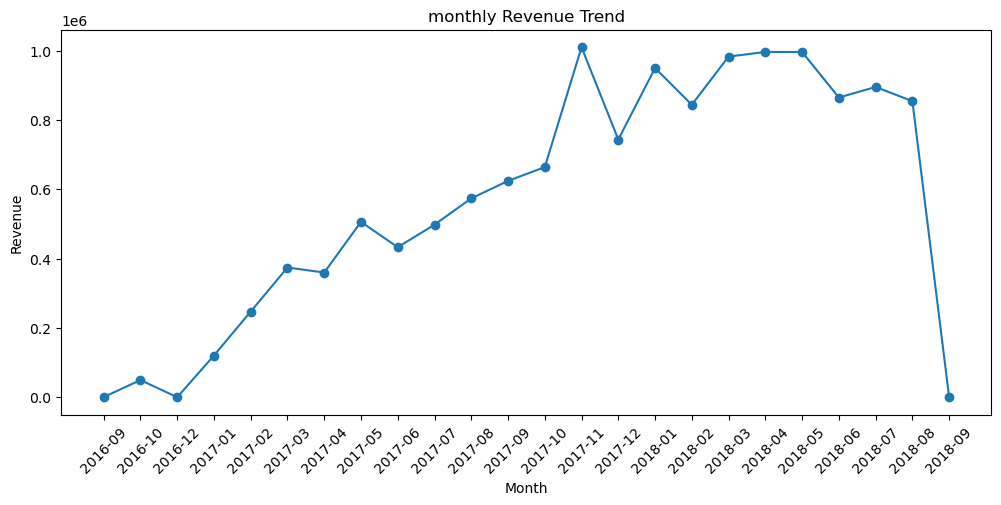

In [50]:
# Q11. What is the monthly revenue trend?
orders_items=orders[['order_id','month']].merge (
    order_items[['order_id','price']],
    on='order_id',
    how='inner')
monthly_revenue=orders_items.groupby('month')['price'].sum()
print(monthly_revenue)
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o'
)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("monthly Revenue Trend")

plt.show()

In [51]:
# Q12. Which order status occurs most frequently?
order_status=orders['order_status'].value_counts()
print(order_status)
most_common_status=orders['order_status'].value_counts().idxmax()
print("most frequent order Status:",most_common_status)




order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
most frequent order Status: delivered


day_name
Friday       14122
Monday       16196
Saturday     10887
Sunday       11960
Thursday     14761
Tuesday      15963
Wednesday    15552
Name: order_id, dtype: int64
highest Order day Monday 16196
highest order month 2017-11 7544


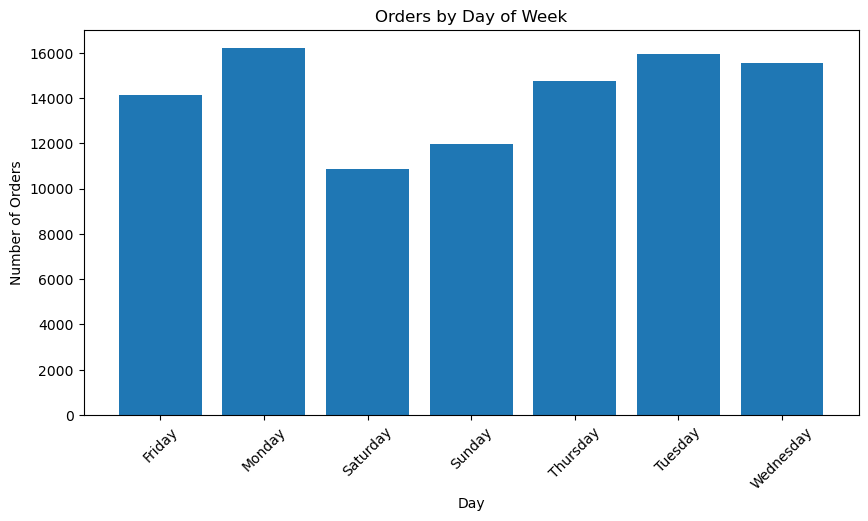

In [60]:
# Q13. Which days/months generated the highest number of orders?
orders['day_name']=orders['order_purchase_timestamp'].dt.day_name()
orders_by_day=orders.groupby('day_name')['order_id'].nunique()
print(orders_by_day)
#find highest
print("highest Order day",orders_by_day.idxmax(),
      orders_by_day.max())

order_by_month=orders.groupby('month')['order_id'].nunique()
print("highest order month",order_by_month.idxmax(),
      order_by_month.max())

#chart presentation
plt.figure(figsize=(10,5))
plt.bar(
    orders_by_day.index,
    orders_by_day.values)

plt.xticks(rotation=45)
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of Week")

plt.show()

In [66]:
items_products = order_items.merge(
    products,
    on='product_id',
    how='left'
)

In [70]:
product_category_translation = pd.read_csv(
    "product_category_name_translation.csv"
)

In [72]:
print(items_products.columns)

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


In [73]:
print(product_category_translation.columns)

Index(['product_category_name', 'product_category_name_english'], dtype='object')


In [74]:
items_products = items_products.merge(
    product_category_translation,
    on='product_category_name',
    how='left'
)

In [76]:
# Q14. Which are the top 10 product categories by number of orders?
category_orders=(
    items_products
    .groupby('product_category_name_english')['order_id']
        .nunique()
        .sort_values(ascending=False)
        .head(10)
        )
print(category_orders)
        


product_category_name_english
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
housewares               5884
watches_gifts            5624
telephony                4199
auto                     3897
toys                     3886
Name: order_id, dtype: int64


product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64


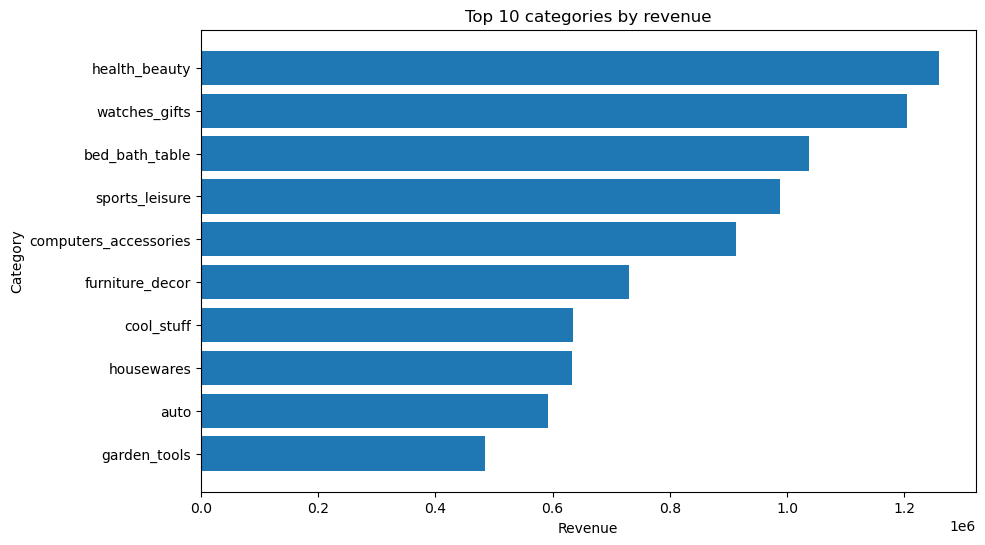

In [83]:
# Q15. Which are the top 10 product categories by revenue?
category_revenue=(items_products
    .groupby('product_category_name_english')['price']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))
print(category_revenue)

plt.figure(figsize=(10,6))
plt.barh(
    category_revenue.index[::-1],
    category_revenue.values[::-1]
)
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.title("Top 10 categories by revenue")

plt.show()

In [84]:

# Q16. Which 10 products generated the highest revenue?

product_revenue = (
    order_items
    .groupby('product_id')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(product_revenue)

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64


In [85]:
# Q17. Which products have the highest quantity sold?
product_quantity = (
    order_items
    .groupby('product_id')['order_item_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(product_quantity)


product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: order_item_id, dtype: int64


In [86]:
# Q18. What is the average product price for each category?

average_category_price = (
    items_products
    .groupby('product_category_name_english')['price']
    .mean()
    .sort_values(ascending=False)
)

print(average_category_price)

product_category_name_english
computers                                1098.340542
small_appliances_home_oven_and_coffee     624.285658
home_appliances_2                         476.124958
agro_industry_and_commerce                342.124858
musical_instruments                       281.616000
                                            ...     
food_drink                                 54.602446
cds_dvds_musicals                          52.142857
diapers_and_hygiene                        40.194615
flowers                                    33.637576
home_comfort_2                             25.342333
Name: price, Length: 71, dtype: float64


In [88]:
# Q19. Which categories have the highest average order value?
category_order_value = (
    items_products
    .groupby([
        'product_category_name_english',
        'order_id'
    ])['price']
    .sum()
    .reset_index()
)

category_aov = (
    category_order_value
    .groupby('product_category_name_english')['price']
    .mean()
    .sort_values(ascending=False)
)

print(category_aov.head(10))

product_category_name_english
computers                                1231.840497
small_appliances_home_oven_and_coffee     632.609467
home_appliances_2                         484.263846
agro_industry_and_commerce                398.519066
musical_instruments                       304.934522
small_appliances                          302.616794
fixed_telephony                           274.576037
construction_tools_safety                 242.781557
air_conditioning                          217.489960
office_furniture                          215.208720
Name: price, dtype: float64


customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
Name: customer_unique_id, dtype: int64


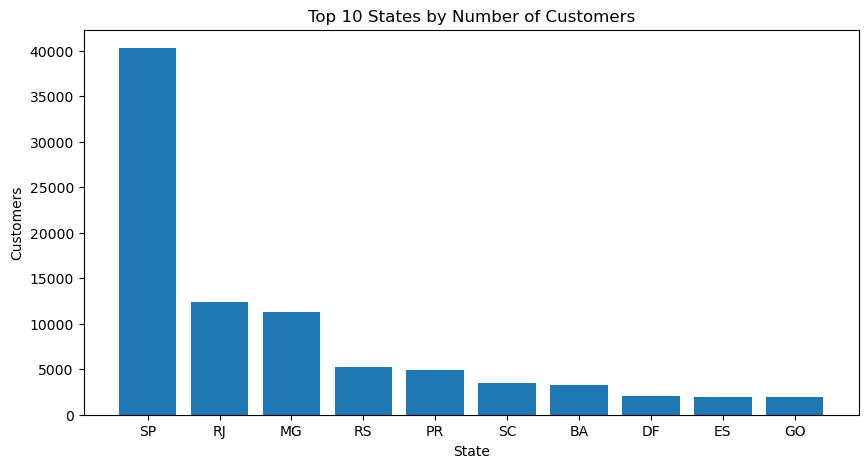

In [89]:
# Q20. Which Brazilian states have the highest number of customers?

customers_by_state = (
    customers
    .groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
)

print(customers_by_state.head(10))


top_states = customers_by_state.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_states.index,
    top_states.values
)

plt.xlabel("State")
plt.ylabel("Customers")
plt.title("Top 10 States by Number of Customers")

plt.show()


In [92]:
# Q21. Which states generate the highest revenue?
customer_orders = customers[
    ['customer_id', 'customer_unique_id', 'customer_state']
].merge(
    orders[['order_id', 'customer_id']],
    on='customer_id',
    how='inner'
)

state_revenue_data = customer_orders.merge(
    order_items[['order_id', 'price']],
    on='order_id',
    how='inner'
)

state_revenue = (
    state_revenue_data
    .groupby('customer_state')['price']
    .sum()
    .sort_values(ascending=False)
)

print(state_revenue.head(10))

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64


In [93]:

# Q22. How many customers placed only one order?

customer_order_count = (
    orders
    .groupby('customer_id')['order_id']
    .nunique()
)

one_order_customers = (customer_order_count == 1).sum()

print("Customers with only one order:", one_order_customers)

Customers with only one order: 99441


In [94]:
# Q23. How many customers placed more than one order?

multiple_order_customers = (customer_order_count > 1).sum()

print(
    "Customers with more than one order:",
    multiple_order_customers
)

Customers with more than one order: 0


In [96]:
# Q24. Who are the top 10 customers based on total spending?
customer_spending_data = orders[
    ['order_id', 'customer_id']
].merge(
    customers[
        ['customer_id', 'customer_unique_id']
    ],
    on='customer_id',
    how='left'
)

customer_spending_data = customer_spending_data.merge(
    order_items[['order_id', 'price']],
    on='order_id',
    how='inner'
)

top_customers = (
    customer_spending_data
    .groupby('customer_unique_id')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.0
da122df9eeddfedc1dc1f5349a1a690c     7388.0
763c8b1c9c68a0229c42c9fc6f662b93     7160.0
dc4802a71eae9be1dd28f5d788ceb526     6735.0
459bef486812aa25204be022145caa62     6729.0
ff4159b92c40ebe40454e3e6a7c35ed6     6499.0
4007669dec559734d6f53e029e360987     5934.6
eebb5dda148d3893cdaf5b5ca3040ccb     4690.0
5d0a2980b292d049061542014e8960bf     4599.9
48e1ac109decbb87765a3eade6854098     4590.0
Name: price, dtype: float64


In [98]:
# Q25. What is the average number of orders per customer?
average_orders_customer = customer_order_count.mean()

print(
    "Average Orders per Customer:",
    average_orders_customer
)


Average Orders per Customer: 1.0


In [99]:
# Q26. What is the average delivery time for completed orders?
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

average_delivery_time = orders['delivery_days'].mean()

print(
    "Average Delivery Time:",
    average_delivery_time,
    "days"
)


Average Delivery Time: 12.094085575687217 days


In [100]:
# Q27. How many orders were delivered later than the estimated delivery date?
orders['is_late'] = (
    orders['order_delivered_customer_date']
    > orders['order_estimated_delivery_date']
)

late_orders = orders['is_late'].sum()

print("Late Orders:", late_orders)

Late Orders: 7827


In [103]:

# Q28. Which product categories have the longest average delivery time?

# Calculate delivery days
orders['delivery_days'] = (
    pd.to_datetime(orders['order_delivered_customer_date']) -
    pd.to_datetime(orders['order_purchase_timestamp'])
).dt.days

# Select required columns and merge with reviews
delivery_reviews = orders[
    ['order_id', 'delivery_days']
].merge(
    order_reviews[
        ['order_id', 'review_score']
    ],
    on='order_id',
    how='inner'
)

# Remove missing values
delivery_reviews = delivery_reviews.dropna(
    subset=['delivery_days', 'review_score']
)

# Calculate correlation
correlation = np.corrcoef(
    delivery_reviews['delivery_days'],
    delivery_reviews['review_score']
)[0, 1]

print("Correlation:", correlation)

Correlation: -0.33366034110477033
